In [ ]:
"""
Гібридні квантово-класичні моделі (PennyLane) для прогнозування pCR
====================================================================

Дані: train.csv / test.csv (8 ознак, вже масштабованих у діапазон [0, pi] —
ідеально підходить для кутового кодування (Angle Embedding)).

Реалізовано 3 архітектури (з переліку 7-ми), обрані як найкращі й найцікавіші
саме для цього датасету (154 навчальних / 39 тестових прикладів, дисбаланс
класів ~2.8:1 на користь "No pCR"):

  1) Quantum Feature Map (AngleEmbedding + StronglyEntanglingLayers,
     фіксована випадкова схема) -> Expectation values -> XGBoost
     [варіант 5/6 зі списку — найперспективніший за рекомендацією]

  2) Quantum Kernel (fidelity kernel на AngleEmbedding) -> Classical SVM
     [варіант 4 — найкращий саме для малих датасетів]

  3) Quantum Feature Extractor (глибша варіаційна схема) -> MLP (нейромережа)
     [варіант 2/6 — квантова схема як генератор нелінійних ознак для NN]

Для кожної моделі рахуються: ROC-AUC, Accuracy, Recall(pCR), F1(pCR),
і будується confusion matrix.
"""

In [ ]:
pip install pennylane

In [ ]:
pip install xgboost

In [18]:
import numpy as np
import pandas as pd
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, recall_score, f1_score, confusion_matrix
)
from xgboost import XGBClassifier

np.random.seed(42)

In [ ]:
# ---------------------------------------------------------------------------
# 1. Завантаження даних
# ---------------------------------------------------------------------------
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

FEATURES = [
    "HER2pos_scaled", "MRI_pct_change_scaled", "MRI_shrinkage_early_scaled",
    "is_TN_scaled", "PgRpos_scaled", "ERpos_scaled",
    "MRI_LD_Baseline_scaled", "age_scaled",
]
TARGET = "PCR"

X_train = train[FEATURES].values
y_train = train[TARGET].values.astype(int)
X_test = test[FEATURES].values
y_test = test[TARGET].values.astype(int)

N_QUBITS = len(FEATURES)  # = 8
print(f"Train: {X_train.shape}, Test: {X_test.shape}, N_QUBITS={N_QUBITS}")
print(f"Train PCR balance: {np.bincount(y_train)}  |  Test PCR balance: {np.bincount(y_test)}")

# class imbalance ratio, corisno для XGBoost scale_pos_weight
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

Train: (154, 8), Test: (39, 8), N_QUBITS=8
Train PCR balance: [113  41]  |  Test PCR balance: [29 10]


In [27]:
def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(4.6, 3.8))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=True,
        xticklabels=["No pCR", "pCR"], yticklabels=["No pCR", "pCR"],
    )
    plt.title(f"{model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    plt.close()
    return cm


def evaluate(model_name, y_true, y_pred, y_proba):
    auc = roc_auc_score(y_true, y_proba)
    acc = accuracy_score(y_true, y_pred)
    rec_pcr = recall_score(y_true, y_pred, pos_label=1)
    f1_pcr = f1_score(y_true, y_pred, pos_label=1)
    cm = plot_confusion(y_true, y_pred, model_name)
    print(f"\n=== {model_name} ===")
    print(f"ROC-AUC       : {auc:.3f}")
    print(f"Accuracy      : {acc:.3f}")
    print(f"Recall (pCR)  : {rec_pcr:.3f}")
    print(f"F1 (pCR)      : {f1_pcr:.3f}")
    print(f"Confusion matrix:\n{cm}")
    return {"model": model_name, "ROC_AUC": auc, "Accuracy": acc,
            "Recall_pCR": rec_pcr, "F1_pCR": f1_pcr}


[Модель 1] Обчислення квантових ознак (feature map)...


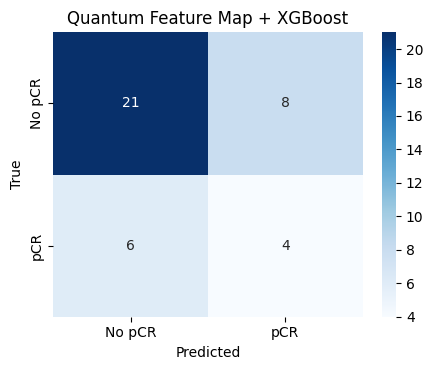


=== Quantum Feature Map + XGBoost ===
ROC-AUC       : 0.603
Accuracy      : 0.641
Recall (pCR)  : 0.400
F1 (pCR)      : 0.364
Confusion matrix:
[[21  8]
 [ 6  4]]


In [28]:
# ===========================================================================
# МОДЕЛЬ 1: Quantum Feature Map (AngleEmbedding + StronglyEntanglingLayers)
#           + XGBoost
# ===========================================================================
dev1 = qml.device("default.qubit", wires=N_QUBITS)
 
N_LAYERS_1 = 2
np.random.seed(0)
weights_1 = np.random.uniform(0, 2 * np.pi, size=(N_LAYERS_1, N_QUBITS, 3))
 
@qml.qnode(dev1)
def feature_map_circuit(x, weights):
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
 
 
def extract_quantum_features(X, weights):
    return np.array([feature_map_circuit(x, weights) for x in X])
 
 
print("\n[Модель 1] Обчислення квантових ознак (feature map)...")
Xq_train_1 = extract_quantum_features(X_train, weights_1)
Xq_test_1 = extract_quantum_features(X_test, weights_1)
 
clf1 = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    scale_pos_weight=pos_weight, eval_metric="logloss", random_state=42,
)
clf1.fit(Xq_train_1, y_train)
proba1 = clf1.predict_proba(Xq_test_1)[:, 1]
pred1 = (proba1 >= 0.5).astype(int)
 
results.append(evaluate(
    "Quantum Feature Map + XGBoost", y_test, pred1, proba1
))


[Модель 2] Обчислення квантової kernel-матриці (це небагато довше)...


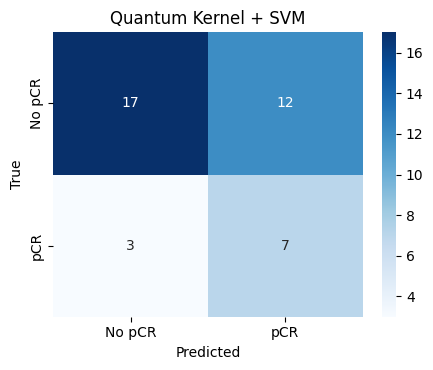


=== Quantum Kernel + SVM ===
ROC-AUC       : 0.710
Accuracy      : 0.615
Recall (pCR)  : 0.700
F1 (pCR)      : 0.483
Confusion matrix:
[[17 12]
 [ 3  7]]


In [29]:
# ===========================================================================
# МОДЕЛЬ 2: Quantum Kernel (fidelity kernel на AngleEmbedding) + SVM
# ===========================================================================
dev2 = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev2)
def kernel_circuit(x1, x2):
    qml.AngleEmbedding(x1, wires=range(N_QUBITS), rotation="Y")
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(N_QUBITS), rotation="Y")
    return qml.probs(wires=range(N_QUBITS))


def quantum_kernel(x1, x2):
    # fidelity = ймовірність виміряти базовий стан |0...0>
    return kernel_circuit(x1, x2)[0]


def build_kernel_matrix(A, B):
    K = np.zeros((len(A), len(B)))
    for i, a in enumerate(A):
        for j, b in enumerate(B):
            K[i, j] = quantum_kernel(a, b)
    return K


print("\n[Модель 2] Обчислення квантової kernel-матриці (це небагато довше)...")
K_train_2 = build_kernel_matrix(X_train, X_train)
K_test_2 = build_kernel_matrix(X_test, X_train)

clf2 = SVC(kernel="precomputed", probability=True, class_weight="balanced", random_state=42)
clf2.fit(K_train_2, y_train)
proba2 = clf2.predict_proba(K_test_2)[:, 1]
pred2 = clf2.predict(K_test_2)

results.append(evaluate(
    "Quantum Kernel + SVM", y_test, pred2, proba2
))


[Модель 3] Обчислення квантових ознак (глибший feature extractor)...


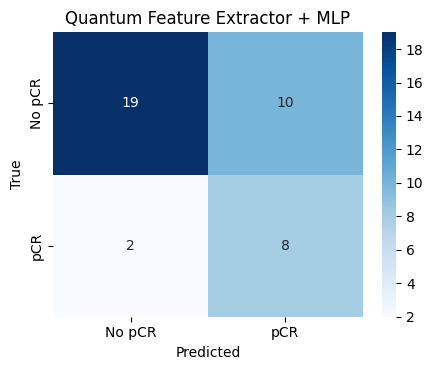


=== Quantum Feature Extractor + MLP ===
ROC-AUC       : 0.797
Accuracy      : 0.692
Recall (pCR)  : 0.800
F1 (pCR)      : 0.571
Confusion matrix:
[[19 10]
 [ 2  8]]


In [30]:
# ===========================================================================
# МОДЕЛЬ 3: Quantum Feature Extractor (глибша схема) + MLP (нейромережа)
# ===========================================================================
dev3 = qml.device("default.qubit", wires=N_QUBITS)

N_LAYERS_3 = 4
np.random.seed(7)
weights_3 = np.random.uniform(0, 2 * np.pi, size=(N_LAYERS_3, N_QUBITS, 3))

@qml.qnode(dev3)
def feature_extractor_circuit(x, weights):
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    # додаємо ще й кореляції між сусідніми кубітами (ZZ) як додаткові ознаки
    z_exp = [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    zz_exp = [qml.expval(qml.PauliZ(i) @ qml.PauliZ(i + 1)) for i in range(N_QUBITS - 1)]
    return z_exp + zz_exp


def extract_quantum_features_v2(X, weights):
    return np.array([feature_extractor_circuit(x, weights) for x in X])


print("\n[Модель 3] Обчислення квантових ознак (глибший feature extractor)...")
Xq_train_3 = extract_quantum_features_v2(X_train, weights_3)
Xq_test_3 = extract_quantum_features_v2(X_test, weights_3)

# нормалізація вже не потрібна: всі значення в [-1, 1]
clf3 = MLPClassifier(
    hidden_layer_sizes=(16, 8), activation="tanh", alpha=1e-2,
    max_iter=2000, random_state=42,
)
clf3.fit(Xq_train_3, y_train)
proba3 = clf3.predict_proba(Xq_test_3)[:, 1]

# оскільки класи незбалансовані, підбираємо поріг за максимумом F1(pCR) на train (без витоку з test)
proba3_train = clf3.predict_proba(Xq_train_3)[:, 1]
best_thr, best_f1 = 0.5, -1
for thr in np.linspace(0.1, 0.9, 33):
    f1_tmp = f1_score(y_train, (proba3_train >= thr).astype(int), pos_label=1)
    if f1_tmp > best_f1:
        best_f1, best_thr = f1_tmp, thr

pred3 = (proba3 >= best_thr).astype(int)

results.append(evaluate(
    "Quantum Feature Extractor + MLP", y_test, pred3, proba3
))

In [31]:
# ===========================================================================
# Зведена таблиця результатів
# ===========================================================================
res_df = pd.DataFrame(results).set_index("model").round(3)
print("\n" + "=" * 70)
print("ЗВЕДЕНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ")
print("=" * 70)
print(res_df.to_string())
res_df.to_csv("results_summary.csv")



ЗВЕДЕНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ
                                 ROC_AUC  Accuracy  Recall_pCR  F1_pCR
model                                                                 
Quantum Feature Map + XGBoost      0.603     0.641         0.4   0.364
Quantum Kernel + SVM               0.710     0.615         0.7   0.483
Quantum Feature Extractor + MLP    0.797     0.692         0.8   0.571
Quantum Feature Map + XGBoost      0.603     0.641         0.4   0.364
Quantum Kernel + SVM               0.710     0.615         0.7   0.483
Quantum Feature Extractor + MLP    0.797     0.692         0.8   0.571
